# 20. 미탐(False Negative) 테스트
## 목적: 후처리(클래스별 Threshold, 연속 프레임 필터) 적용 후에도 진짜 화재를 탐지하는지 검증
---
- **테스트 시나리오 3단계**
  1. 기본 (Threshold 0.10, 필터 없음)
  2. 클래스별 Threshold 적용 (fire: 0.10, smoke: 0.25)
  3. 클래스별 Threshold + 연속 10프레임 필터
- **TDD 기준**: 3개 영상 모두 3단계 전부 탐지 성공해야 PASS

## 셀 1: 설정값 및 라이브러리 임포트

In [1]:
# ============ 설정값 (여기서 조절) ============
FIRE_THRESHOLD = 0.10        # fire 클래스 confidence 임계값
SMOKE_THRESHOLD = 0.25       # smoke 클래스 confidence 임계값
CONSECUTIVE_FRAMES = 10      # 연속 프레임 필터 기준 (N프레임 연속 탐지 시 알람)
BASE_THRESHOLD = 0.10        # 기본 시나리오에서 사용할 단일 임계값
# =============================================

# ============ 경로 설정 ============
import os  # 파일/폴더 경로 처리용 모듈

# 프로젝트 최상위 경로
PROJECT_DIR = r"N:\개인\이수빈\3.13_Mini_Project"

# YOLOv8n Tuned 모델 가중치 경로
MODEL_PATH = os.path.join(PROJECT_DIR, "results", "yolov8n_tuned", "weights", "best.pt")

# 테스트 영상이 들어있는 폴더 경로
VIDEO_DIR = os.path.join(PROJECT_DIR, "DATASET", "테스트영상", "미탐 테스트")

# 결과 저장 폴더 경로
RESULT_DIR = os.path.join(PROJECT_DIR, "results", "false_negative_test")

# 결과 폴더가 없으면 생성
os.makedirs(RESULT_DIR, exist_ok=True)
# ==================================

# ============ 테스트 영상 정보 ============
# 각 영상의 파일명과 특성 정보를 딕셔너리로 정의
VIDEO_INFO = {
    "화재녹음5.mp4": {"start": "0초부터", "type": "연기+불꽃", "size": "보통"},
    "화재녹음6.mp4": {"start": "0초부터", "type": "연기+불꽃", "size": "보통"},
    "화재녹음7.mp4": {"start": "중간부터", "type": "연기+불꽃", "size": "작음"},
}
# =========================================

# ============ 클래스 인덱스 ============
FIRE_CLASS = 0   # fire 클래스 인덱스
SMOKE_CLASS = 1  # smoke 클래스 인덱스
CLASS_NAMES = {0: "fire", 1: "smoke"}  # 인덱스 → 이름 매핑
# ======================================

# ============ 추론 장치 ============
DEVICE = "cpu"  # CPU로 추론 수행
# ==================================

# ============ 라이브러리 임포트 ============
import cv2                          # OpenCV: 영상 읽기/처리
import numpy as np                  # 수치 연산용
import matplotlib.pyplot as plt     # 시각화(그래프/차트)
import matplotlib.font_manager as fm  # 한글 폰트 설정용
from collections import defaultdict   # 기본값이 있는 딕셔너리
from ultralytics import YOLO          # YOLOv8 모델 로드/추론
import warnings                       # 경고 메시지 숨기기용
warnings.filterwarnings('ignore')     # 불필요한 경고 숨김
# ==========================================

# ============ 한글 폰트 설정 ============
plt.rcParams['font.family'] = 'Malgun Gothic'  # 맑은 고딕 폰트 사용
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지
# ========================================

# 설정 확인 출력
print("=" * 60)  # 구분선
print("[설정 확인]")  # 제목
print(f"  모델 경로: {MODEL_PATH}")  # 모델 파일 위치
print(f"  영상 폴더: {VIDEO_DIR}")  # 테스트 영상 폴더
print(f"  결과 저장: {RESULT_DIR}")  # 결과 저장 폴더
print(f"  장치: {DEVICE}")  # 추론 장치
print(f"  기본 Threshold: {BASE_THRESHOLD}")  # 시나리오1 임계값
print(f"  Fire Threshold: {FIRE_THRESHOLD}")  # 시나리오2,3 fire 임계값
print(f"  Smoke Threshold: {SMOKE_THRESHOLD}")  # 시나리오2,3 smoke 임계값
print(f"  연속 프레임 기준: {CONSECUTIVE_FRAMES}프레임")  # 시나리오3 필터 기준
print("=" * 60)  # 구분선

# 영상 파일 존재 여부 확인
print("\n[영상 파일 확인]")  # 제목
for vname in VIDEO_INFO:  # 각 영상 파일에 대해
    vpath = os.path.join(VIDEO_DIR, vname)  # 전체 경로 조합
    exists = os.path.exists(vpath)  # 파일 존재 여부 확인
    status = "✅ 존재" if exists else "❌ 없음"  # 상태 표시
    print(f"  {vname}: {status}")  # 결과 출력

[설정 확인]
  모델 경로: N:\개인\이수빈\3.13_Mini_Project\results\yolov8n_tuned\weights\best.pt
  영상 폴더: N:\개인\이수빈\3.13_Mini_Project\DATASET\테스트영상\미탐 테스트
  결과 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test
  장치: cpu
  기본 Threshold: 0.1
  Fire Threshold: 0.1
  Smoke Threshold: 0.25
  연속 프레임 기준: 10프레임

[영상 파일 확인]
  화재녹음5.mp4: ✅ 존재
  화재녹음6.mp4: ✅ 존재
  화재녹음7.mp4: ✅ 존재


## 셀 2: 모델 로드 및 검증

In [2]:
# ============ 모델 로드 ============
# YOLOv8n Tuned 모델을 로드한다
model = YOLO(MODEL_PATH)  # best.pt 가중치 파일에서 모델 불러오기

# 모델 정보 출력
print("[모델 로드 완료]")  # 로드 성공 메시지
print(f"  모델 타입: {model.overrides.get('model', 'N/A')}")  # 모델 유형
print(f"  클래스 수: {len(model.names)}")  # 학습된 클래스 개수
print(f"  클래스 목록: {model.names}")  # 클래스 이름 목록

# 클래스 인덱스 검증 (fire=0, smoke=1인지 확인)
assert model.names[0].lower() in ['fire', '0'], f"클래스 0이 fire가 아님: {model.names[0]}"  # fire 확인
print("\n  ✅ 클래스 인덱스 검증 통과 (fire=0, smoke=1)")  # 검증 성공 메시지

[모델 로드 완료]
  모델 타입: N:\개인\이수빈\3.13_Mini_Project\results\yolov8n_tuned\weights\best.pt
  클래스 수: 2
  클래스 목록: {0: 'fire', 1: 'smoke'}

  ✅ 클래스 인덱스 검증 통과 (fire=0, smoke=1)


## 셀 3: 핵심 분석 함수 정의

In [3]:
def analyze_video_scenario1(video_path, model, threshold):
    """
    시나리오 1: 기본 탐지 (단일 threshold, 필터 없음)
    모든 클래스에 동일한 threshold를 적용하고, 연속 프레임 필터 없이 탐지.
    
    Args:
        video_path: 영상 파일 경로
        model: YOLO 모델 객체
        threshold: confidence 임계값 (모든 클래스 동일)
    
    Returns:
        dict: 분석 결과 (탐지 프레임 수, 클래스별 정보, 샘플 프레임 등)
    """
    cap = cv2.VideoCapture(video_path)  # 영상 파일 열기
    fps = cap.get(cv2.CAP_PROP_FPS)    # 초당 프레임 수 가져오기
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 전체 프레임 수
    
    # 결과 저장용 변수들 초기화
    detected_frames = []        # 탐지된 프레임 번호 리스트
    fire_frames = []            # fire가 탐지된 프레임 번호 리스트
    smoke_frames = []           # smoke가 탐지된 프레임 번호 리스트
    all_confidences = []        # 모든 탐지의 confidence 값 리스트
    fire_confidences = []       # fire 탐지의 confidence 값 리스트
    smoke_confidences = []      # smoke 탐지의 confidence 값 리스트
    sample_frames_data = []     # 샘플 프레임 이미지 저장용 리스트
    frame_timeline = {}         # 프레임별 탐지 여부 기록 (타임라인용)
    
    frame_idx = 0  # 현재 프레임 번호 카운터
    
    while cap.isOpened():  # 영상이 열려있는 동안 반복
        ret, frame = cap.read()  # 한 프레임 읽기 (ret: 성공여부, frame: 이미지)
        if not ret:  # 더 이상 읽을 프레임이 없으면
            break  # 반복 종료
        
        # YOLO 모델로 추론 수행
        results = model.predict(
            frame,           # 입력 이미지
            conf=threshold,  # confidence 임계값
            device=DEVICE,   # 추론 장치 (cpu)
            verbose=False    # 추론 로그 숨김
        )
        
        # 탐지 결과 처리
        boxes = results[0].boxes  # 탐지된 바운딩 박스 정보
        frame_detected = False     # 이 프레임에서 탐지 여부 플래그
        frame_has_fire = False     # 이 프레임에서 fire 탐지 여부
        frame_has_smoke = False    # 이 프레임에서 smoke 탐지 여부
        
        if len(boxes) > 0:  # 탐지된 객체가 있으면
            for box in boxes:  # 각 바운딩 박스에 대해
                cls_id = int(box.cls[0])    # 클래스 인덱스 추출
                conf = float(box.conf[0])   # confidence 값 추출
                
                frame_detected = True       # 탐지됨으로 표시
                all_confidences.append(conf)  # 전체 confidence 기록
                
                if cls_id == FIRE_CLASS:      # fire 클래스인 경우
                    frame_has_fire = True     # fire 탐지 표시
                    fire_confidences.append(conf)  # fire confidence 기록
                elif cls_id == SMOKE_CLASS:   # smoke 클래스인 경우
                    frame_has_smoke = True    # smoke 탐지 표시
                    smoke_confidences.append(conf)  # smoke confidence 기록
        
        # 탐지 결과를 각 리스트에 기록
        if frame_detected:  # 이 프레임에서 뭔가 탐지되었으면
            detected_frames.append(frame_idx)  # 탐지 프레임 목록에 추가
        if frame_has_fire:  # fire가 탐지되었으면
            fire_frames.append(frame_idx)  # fire 프레임 목록에 추가
        if frame_has_smoke:  # smoke가 탐지되었으면
            smoke_frames.append(frame_idx)  # smoke 프레임 목록에 추가
        
        # 타임라인 기록 (이 프레임에서 무엇이 탐지되었는지)
        frame_timeline[frame_idx] = {
            "detected": frame_detected,    # 전체 탐지 여부
            "fire": frame_has_fire,         # fire 탐지 여부
            "smoke": frame_has_smoke,       # smoke 탐지 여부
            "time_sec": frame_idx / fps if fps > 0 else 0  # 시간(초) 변환
        }
        
        # 샘플 프레임 저장 (탐지된 프레임 중 최대 3장)
        if frame_detected and len(sample_frames_data) < 3:  # 3장까지만
            # 탐지 결과를 프레임 위에 그리기 (바운딩 박스 + 레이블)
            annotated = results[0].plot()  # YOLO가 제공하는 시각화 함수
            sample_frames_data.append({   # 샘플 정보 저장
                "frame_idx": frame_idx,   # 프레임 번호
                "time_sec": frame_idx / fps if fps > 0 else 0,  # 시간(초)
                "image": annotated         # 어노테이션된 이미지
            })
        
        frame_idx += 1  # 다음 프레임으로
    
    cap.release()  # 영상 파일 닫기
    
    # 결과 딕셔너리 구성하여 반환
    return {
        "total_frames": total_frames,       # 전체 프레임 수
        "fps": fps,                          # FPS
        "detected_count": len(detected_frames),    # 탐지된 프레임 수
        "fire_count": len(fire_frames),             # fire 탐지 프레임 수
        "smoke_count": len(smoke_frames),           # smoke 탐지 프레임 수
        "detected_frames": detected_frames,         # 탐지 프레임 번호 리스트
        "fire_frames": fire_frames,                 # fire 프레임 번호 리스트
        "smoke_frames": smoke_frames,               # smoke 프레임 번호 리스트
        "all_conf_range": (min(all_confidences), max(all_confidences)) if all_confidences else (0, 0),  # 전체 conf 범위
        "fire_conf_range": (min(fire_confidences), max(fire_confidences)) if fire_confidences else (0, 0),  # fire conf 범위
        "smoke_conf_range": (min(smoke_confidences), max(smoke_confidences)) if smoke_confidences else (0, 0),  # smoke conf 범위
        "sample_frames": sample_frames_data,  # 샘플 프레임 이미지들
        "timeline": frame_timeline,           # 프레임별 타임라인
    }


def analyze_video_scenario2(video_path, model, fire_thresh, smoke_thresh):
    """
    시나리오 2: 클래스별 Threshold 적용 (필터 없음)
    fire와 smoke에 서로 다른 threshold를 적용한다.
    모델 추론은 낮은 threshold(fire)로 수행하고, smoke는 후처리로 필터링.
    
    Args:
        video_path: 영상 파일 경로
        model: YOLO 모델 객체
        fire_thresh: fire 클래스 confidence 임계값
        smoke_thresh: smoke 클래스 confidence 임계값
    
    Returns:
        dict: 분석 결과
    """
    cap = cv2.VideoCapture(video_path)  # 영상 열기
    fps = cap.get(cv2.CAP_PROP_FPS)    # FPS
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 전체 프레임 수
    
    # 결과 저장용 변수들
    detected_frames = []       # 탐지 프레임 리스트
    fire_frames = []           # fire 프레임 리스트
    smoke_frames = []          # smoke 프레임 리스트
    all_confidences = []       # 전체 confidence 리스트
    fire_confidences = []      # fire confidence 리스트
    smoke_confidences = []     # smoke confidence 리스트
    sample_frames_data = []    # 샘플 프레임 리스트
    frame_timeline = {}        # 타임라인 딕셔너리
    
    # 모델 추론에 사용할 threshold는 더 낮은 값 (fire threshold)
    min_thresh = min(fire_thresh, smoke_thresh)  # 둘 중 낮은 값 선택
    
    frame_idx = 0  # 프레임 카운터
    
    while cap.isOpened():  # 영상이 열려있는 동안
        ret, frame = cap.read()  # 프레임 읽기
        if not ret:  # 프레임 없으면
            break  # 종료
        
        # 낮은 threshold로 추론 (후처리에서 클래스별 필터링)
        results = model.predict(
            frame,              # 입력 이미지
            conf=min_thresh,    # 최소 threshold로 추론
            device=DEVICE,      # CPU
            verbose=False       # 로그 숨김
        )
        
        boxes = results[0].boxes  # 탐지된 박스들
        frame_detected = False    # 프레임 탐지 플래그
        frame_has_fire = False    # fire 탐지 플래그
        frame_has_smoke = False   # smoke 탐지 플래그
        
        if len(boxes) > 0:  # 탐지 결과가 있으면
            for box in boxes:  # 각 박스에 대해
                cls_id = int(box.cls[0])   # 클래스 ID
                conf = float(box.conf[0])  # confidence 값
                
                # ★ 핵심: 클래스별 threshold 적용
                if cls_id == FIRE_CLASS and conf >= fire_thresh:  # fire이고 threshold 이상
                    frame_detected = True          # 탐지됨
                    frame_has_fire = True           # fire 탐지
                    all_confidences.append(conf)    # confidence 기록
                    fire_confidences.append(conf)   # fire confidence 기록
                elif cls_id == SMOKE_CLASS and conf >= smoke_thresh:  # smoke이고 threshold 이상
                    frame_detected = True           # 탐지됨
                    frame_has_smoke = True          # smoke 탐지
                    all_confidences.append(conf)    # confidence 기록
                    smoke_confidences.append(conf)  # smoke confidence 기록
        
        # 프레임 결과 기록
        if frame_detected:  # 탐지되었으면
            detected_frames.append(frame_idx)  # 목록에 추가
        if frame_has_fire:  # fire 탐지
            fire_frames.append(frame_idx)  # 목록에 추가
        if frame_has_smoke:  # smoke 탐지
            smoke_frames.append(frame_idx)  # 목록에 추가
        
        # 타임라인 기록
        frame_timeline[frame_idx] = {
            "detected": frame_detected,
            "fire": frame_has_fire,
            "smoke": frame_has_smoke,
            "time_sec": frame_idx / fps if fps > 0 else 0
        }
        
        # 샘플 프레임 저장 (최대 3장)
        if frame_detected and len(sample_frames_data) < 3:
            annotated = results[0].plot()  # 시각화
            sample_frames_data.append({
                "frame_idx": frame_idx,
                "time_sec": frame_idx / fps if fps > 0 else 0,
                "image": annotated
            })
        
        frame_idx += 1  # 다음 프레임
    
    cap.release()  # 영상 닫기
    
    return {
        "total_frames": total_frames,
        "fps": fps,
        "detected_count": len(detected_frames),
        "fire_count": len(fire_frames),
        "smoke_count": len(smoke_frames),
        "detected_frames": detected_frames,
        "fire_frames": fire_frames,
        "smoke_frames": smoke_frames,
        "all_conf_range": (min(all_confidences), max(all_confidences)) if all_confidences else (0, 0),
        "fire_conf_range": (min(fire_confidences), max(fire_confidences)) if fire_confidences else (0, 0),
        "smoke_conf_range": (min(smoke_confidences), max(smoke_confidences)) if smoke_confidences else (0, 0),
        "sample_frames": sample_frames_data,
        "timeline": frame_timeline,
    }


def analyze_video_scenario3(video_path, model, fire_thresh, smoke_thresh, consec_frames):
    """
    시나리오 3: 클래스별 Threshold + 연속 N프레임 필터
    클래스별 threshold 적용 후, N프레임 연속 탐지된 경우에만 '확정 탐지'로 처리.
    
    Args:
        video_path: 영상 파일 경로
        model: YOLO 모델 객체
        fire_thresh: fire confidence 임계값
        smoke_thresh: smoke confidence 임계값
        consec_frames: 연속 프레임 수 기준
    
    Returns:
        dict: 분석 결과 (연속 필터 적용된 결과 포함)
    """
    cap = cv2.VideoCapture(video_path)  # 영상 열기
    fps = cap.get(cv2.CAP_PROP_FPS)    # FPS
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 전체 프레임 수
    
    min_thresh = min(fire_thresh, smoke_thresh)  # 추론용 최소 threshold
    
    # ★ 연속 프레임 카운터
    consecutive_count = 0        # 현재 연속 탐지 중인 프레임 수
    alarm_triggered = False      # 알람(확정 탐지)이 발동되었는지
    alarm_frame = -1             # 알람이 처음 발동된 프레임 번호
    
    # 결과 저장용 변수들
    raw_detected_frames = []     # (필터 전) 탐지된 프레임
    filtered_detected_frames = []  # (필터 후) 확정 탐지 프레임
    fire_frames = []             # fire 탐지 프레임
    smoke_frames = []            # smoke 탐지 프레임
    all_confidences = []         # 전체 confidence
    fire_confidences = []        # fire confidence
    smoke_confidences = []       # smoke confidence
    sample_frames_data = []      # 샘플 프레임
    frame_timeline = {}          # 타임라인
    
    frame_idx = 0  # 프레임 카운터
    
    while cap.isOpened():  # 영상 열려있는 동안
        ret, frame = cap.read()  # 프레임 읽기
        if not ret:  # 없으면
            break  # 종료
        
        # 추론 수행
        results = model.predict(
            frame,
            conf=min_thresh,
            device=DEVICE,
            verbose=False
        )
        
        boxes = results[0].boxes
        frame_detected = False    # 이 프레임 탐지 여부 (클래스별 threshold 적용 후)
        frame_has_fire = False
        frame_has_smoke = False
        
        if len(boxes) > 0:  # 탐지 결과 있으면
            for box in boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                
                # 클래스별 threshold 적용
                if cls_id == FIRE_CLASS and conf >= fire_thresh:
                    frame_detected = True
                    frame_has_fire = True
                    all_confidences.append(conf)
                    fire_confidences.append(conf)
                elif cls_id == SMOKE_CLASS and conf >= smoke_thresh:
                    frame_detected = True
                    frame_has_smoke = True
                    all_confidences.append(conf)
                    smoke_confidences.append(conf)
        
        # ★ 연속 프레임 필터 로직
        if frame_detected:  # 이 프레임에서 탐지됨
            raw_detected_frames.append(frame_idx)  # 필터 전 목록에 추가
            consecutive_count += 1  # 연속 카운터 증가
            
            if consecutive_count >= consec_frames:  # N프레임 연속 달성
                if not alarm_triggered:  # 처음 알람이면
                    alarm_triggered = True  # 알람 발동 표시
                    alarm_frame = frame_idx  # 발동 프레임 기록
                filtered_detected_frames.append(frame_idx)  # 확정 목록에 추가
        else:  # 탐지 안 됨
            consecutive_count = 0  # 연속 카운터 리셋
        
        if frame_has_fire:  # fire 탐지
            fire_frames.append(frame_idx)
        if frame_has_smoke:  # smoke 탐지
            smoke_frames.append(frame_idx)
        
        # 타임라인 기록 (연속 필터 상태도 포함)
        frame_timeline[frame_idx] = {
            "detected": frame_detected,          # 클래스별 threshold 통과 여부
            "fire": frame_has_fire,               # fire 여부
            "smoke": frame_has_smoke,             # smoke 여부
            "consecutive": consecutive_count,     # 현재 연속 카운트
            "alarm": alarm_triggered,             # 알람 발동 여부
            "time_sec": frame_idx / fps if fps > 0 else 0
        }
        
        # 샘플 프레임 (알람 발동 후 프레임 저장, 최대 3장)
        if alarm_triggered and frame_detected and len(sample_frames_data) < 3:
            annotated = results[0].plot()
            sample_frames_data.append({
                "frame_idx": frame_idx,
                "time_sec": frame_idx / fps if fps > 0 else 0,
                "image": annotated
            })
        
        frame_idx += 1  # 다음 프레임
    
    cap.release()  # 영상 닫기
    
    return {
        "total_frames": total_frames,
        "fps": fps,
        "raw_detected_count": len(raw_detected_frames),      # 필터 전 탐지 프레임 수
        "detected_count": len(filtered_detected_frames),     # 필터 후 확정 탐지 프레임 수
        "fire_count": len(fire_frames),
        "smoke_count": len(smoke_frames),
        "detected_frames": filtered_detected_frames,         # 확정 탐지 프레임 리스트
        "raw_detected_frames": raw_detected_frames,          # 필터 전 탐지 프레임 리스트
        "fire_frames": fire_frames,
        "smoke_frames": smoke_frames,
        "alarm_triggered": alarm_triggered,                  # 알람 발동 여부
        "alarm_frame": alarm_frame,                          # 알람 발동 프레임 번호
        "alarm_time_sec": alarm_frame / fps if alarm_frame >= 0 and fps > 0 else -1,  # 알람 발동 시간(초)
        "all_conf_range": (min(all_confidences), max(all_confidences)) if all_confidences else (0, 0),
        "fire_conf_range": (min(fire_confidences), max(fire_confidences)) if fire_confidences else (0, 0),
        "smoke_conf_range": (min(smoke_confidences), max(smoke_confidences)) if smoke_confidences else (0, 0),
        "sample_frames": sample_frames_data,
        "timeline": frame_timeline,
    }


print("✅ 분석 함수 3개 정의 완료")  # 완료 메시지
print("  - analyze_video_scenario1(): 기본 탐지")  # 시나리오1
print("  - analyze_video_scenario2(): 클래스별 Threshold")  # 시나리오2
print("  - analyze_video_scenario3(): 클래스별 Threshold + 연속 프레임 필터")  # 시나리오3

✅ 분석 함수 3개 정의 완료
  - analyze_video_scenario1(): 기본 탐지
  - analyze_video_scenario2(): 클래스별 Threshold
  - analyze_video_scenario3(): 클래스별 Threshold + 연속 프레임 필터


## 셀 4: 전체 영상 × 3단계 시나리오 분석 실행

In [4]:
# ============ 전체 분석 실행 ============
# 모든 결과를 저장할 중첩 딕셔너리
# 구조: all_results[영상이름][시나리오번호] = 결과 딕셔너리
all_results = {}

# 각 영상에 대해 3개 시나리오 실행
for video_name, info in VIDEO_INFO.items():  # 영상 3개 순회
    video_path = os.path.join(VIDEO_DIR, video_name)  # 영상 전체 경로
    
    # 영상 파일 존재 확인
    if not os.path.exists(video_path):  # 파일이 없으면
        print(f"❌ 영상 없음: {video_name}")  # 경고 메시지
        continue  # 다음 영상으로 넘어감
    
    print(f"\n{'='*60}")  # 구분선
    print(f"🎬 분석 중: {video_name} ({info['start']}, {info['type']}, {info['size']})")  # 영상 정보
    print(f"{'='*60}")  # 구분선
    
    all_results[video_name] = {}  # 이 영상의 결과 딕셔너리 초기화
    
    # --- 시나리오 1: 기본 ---
    print(f"\n  📌 시나리오 1: 기본 (Threshold={BASE_THRESHOLD}, 필터 없음)")  # 시나리오 설명
    result1 = analyze_video_scenario1(video_path, model, BASE_THRESHOLD)  # 분석 실행
    all_results[video_name]["S1"] = result1  # 결과 저장
    print(f"     탐지 프레임: {result1['detected_count']}/{result1['total_frames']}")  # 탐지 수
    print(f"     fire: {result1['fire_count']}프레임, smoke: {result1['smoke_count']}프레임")  # 클래스별
    print(f"     conf 범위: {result1['all_conf_range'][0]:.3f} ~ {result1['all_conf_range'][1]:.3f}")  # conf 범위
    
    # --- 시나리오 2: 클래스별 Threshold ---
    print(f"\n  📌 시나리오 2: 클래스별 Threshold (fire={FIRE_THRESHOLD}, smoke={SMOKE_THRESHOLD})")  # 설명
    result2 = analyze_video_scenario2(video_path, model, FIRE_THRESHOLD, SMOKE_THRESHOLD)  # 분석 실행
    all_results[video_name]["S2"] = result2  # 결과 저장
    print(f"     탐지 프레임: {result2['detected_count']}/{result2['total_frames']}")  # 탐지 수
    print(f"     fire: {result2['fire_count']}프레임, smoke: {result2['smoke_count']}프레임")  # 클래스별
    print(f"     conf 범위: {result2['all_conf_range'][0]:.3f} ~ {result2['all_conf_range'][1]:.3f}")  # conf 범위
    
    # --- 시나리오 3: 클래스별 Threshold + 연속 프레임 필터 ---
    print(f"\n  📌 시나리오 3: 클래스별 Threshold + 연속 {CONSECUTIVE_FRAMES}프레임 필터")  # 설명
    result3 = analyze_video_scenario3(video_path, model, FIRE_THRESHOLD, SMOKE_THRESHOLD, CONSECUTIVE_FRAMES)  # 분석
    all_results[video_name]["S3"] = result3  # 결과 저장
    print(f"     필터 전 탐지: {result3['raw_detected_count']}프레임")  # 필터 전 수
    print(f"     필터 후 확정: {result3['detected_count']}프레임")  # 필터 후 수
    print(f"     알람 발동: {'✅ Yes' if result3['alarm_triggered'] else '❌ No'}")  # 알람 상태
    if result3['alarm_triggered']:  # 알람 발동 시
        print(f"     알람 시점: {result3['alarm_time_sec']:.1f}초 (프레임 #{result3['alarm_frame']})")  # 발동 시간

print(f"\n\n{'='*60}")  # 구분선
print("✅ 전체 분석 완료!")  # 완료 메시지
print(f"{'='*60}")  # 구분선


🎬 분석 중: 화재녹음5.mp4 (0초부터, 연기+불꽃, 보통)

  📌 시나리오 1: 기본 (Threshold=0.1, 필터 없음)
     탐지 프레임: 476/573
     fire: 368프레임, smoke: 418프레임
     conf 범위: 0.100 ~ 0.860

  📌 시나리오 2: 클래스별 Threshold (fire=0.1, smoke=0.25)
     탐지 프레임: 426/573
     fire: 368프레임, smoke: 247프레임
     conf 범위: 0.100 ~ 0.860

  📌 시나리오 3: 클래스별 Threshold + 연속 10프레임 필터
     필터 전 탐지: 426프레임
     필터 후 확정: 301프레임
     알람 발동: ✅ Yes
     알람 시점: 0.3초 (프레임 #9)

🎬 분석 중: 화재녹음6.mp4 (0초부터, 연기+불꽃, 보통)

  📌 시나리오 1: 기본 (Threshold=0.1, 필터 없음)
     탐지 프레임: 484/703
     fire: 430프레임, smoke: 328프레임
     conf 범위: 0.100 ~ 0.847

  📌 시나리오 2: 클래스별 Threshold (fire=0.1, smoke=0.25)
     탐지 프레임: 450/703
     fire: 430프레임, smoke: 174프레임
     conf 범위: 0.100 ~ 0.847

  📌 시나리오 3: 클래스별 Threshold + 연속 10프레임 필터
     필터 전 탐지: 450프레임
     필터 후 확정: 357프레임
     알람 발동: ✅ Yes
     알람 시점: 5.7초 (프레임 #170)

🎬 분석 중: 화재녹음7.mp4 (중간부터, 연기+불꽃, 작음)

  📌 시나리오 1: 기본 (Threshold=0.1, 필터 없음)
     탐지 프레임: 465/1586
     fire: 329프레임, smoke: 298프레임
     conf 범위: 0.100 ~ 0.650



## 셀 5: TDD 검증 — 미탐 테스트 PASS/FAIL 판정

In [5]:
# ============ TDD 검증 ============
# 각 영상이 각 시나리오에서 탐지에 성공하는지 판정
print("\n" + "=" * 70)  # 구분선
print("🧪 TDD 미탐(False Negative) 테스트 결과")  # 제목
print("=" * 70)  # 구분선

# 전체 테스트 통과 여부 추적
all_pass = True  # 전체 통과 플래그 (하나라도 실패하면 False)

# TDD 결과를 저장할 딕셔너리 (시각화에서 재사용)
tdd_results = {}  # {영상이름: {시나리오: True/False}}

for video_name in VIDEO_INFO:  # 각 영상에 대해
    if video_name not in all_results:  # 분석 결과가 없으면 (파일 없음 등)
        print(f"\n  ⚠️ {video_name}: 분석 결과 없음 (파일 미존재?)")  # 경고
        all_pass = False  # 전체 실패
        continue  # 다음 영상으로
    
    print(f"\n  📹 {video_name}:")  # 영상 이름
    tdd_results[video_name] = {}  # 이 영상의 TDD 결과 딕셔너리
    
    # 시나리오 1 판정: 기본 설정에서 1프레임이라도 탐지되면 PASS
    s1 = all_results[video_name]["S1"]  # 시나리오1 결과
    s1_pass = s1["detected_count"] > 0   # 탐지 프레임이 1개 이상이면 통과
    tdd_results[video_name]["S1"] = s1_pass  # 결과 저장
    status1 = "✅ PASS" if s1_pass else "❌ FAIL"  # 상태 문자열
    print(f"     시나리오1 (기본 Th=0.10):         {status1} ({s1['detected_count']}프레임 탐지)")  # 출력
    if not s1_pass:  # 실패 시
        all_pass = False  # 전체 실패
        print(f"        ⚠️ 기본 설정에서도 미탐 발생! 모델 재검토 필요")  # 경고
    
    # 시나리오 2 판정: 클래스별 threshold에서 1프레임이라도 탐지되면 PASS
    s2 = all_results[video_name]["S2"]  # 시나리오2 결과
    s2_pass = s2["detected_count"] > 0   # 1프레임 이상 탐지면 통과
    tdd_results[video_name]["S2"] = s2_pass  # 결과 저장
    status2 = "✅ PASS" if s2_pass else "❌ FAIL"  # 상태 문자열
    print(f"     시나리오2 (fire={FIRE_THRESHOLD}, smoke={SMOKE_THRESHOLD}): {status2} ({s2['detected_count']}프레임 탐지)")  # 출력
    if not s2_pass:  # 실패 시
        all_pass = False  # 전체 실패
        print(f"        ⚠️ 클래스별 Threshold 적용 후 미탐! Threshold 재조정 필요")  # 경고
    
    # 시나리오 3 판정: 연속 프레임 필터 후 알람이 발동되면 PASS
    s3 = all_results[video_name]["S3"]  # 시나리오3 결과
    s3_pass = s3["alarm_triggered"]       # 알람 발동 여부로 판정
    tdd_results[video_name]["S3"] = s3_pass  # 결과 저장
    status3 = "✅ PASS" if s3_pass else "❌ FAIL"  # 상태 문자열
    detail3 = f"알람 {s3['alarm_time_sec']:.1f}초" if s3_pass else f"연속 {CONSECUTIVE_FRAMES}프레임 미달성"  # 상세
    print(f"     시나리오3 (+ 연속 {CONSECUTIVE_FRAMES}프레임):       {status3} ({detail3})")  # 출력
    if not s3_pass:  # 실패 시
        all_pass = False  # 전체 실패
        print(f"        ⚠️ 연속 프레임 필터에서 미탐! 필터 프레임 수 조정 필요 (현재: {CONSECUTIVE_FRAMES})")  # 경고

# 최종 판정
print(f"\n{'='*70}")  # 구분선
if all_pass:  # 전체 통과
    print("🎉 최종 결과: ALL PASS — 후처리 적용 후에도 모든 화재 영상 탐지 성공!")  # 성공
else:  # 실패 있음
    print("⚠️ 최종 결과: FAIL 존재 — 위의 실패 항목 확인 후 설정 조정 필요")  # 실패
print(f"{'='*70}")  # 구분선


🧪 TDD 미탐(False Negative) 테스트 결과

  📹 화재녹음5.mp4:
     시나리오1 (기본 Th=0.10):         ✅ PASS (476프레임 탐지)
     시나리오2 (fire=0.1, smoke=0.25): ✅ PASS (426프레임 탐지)
     시나리오3 (+ 연속 10프레임):       ✅ PASS (알람 0.3초)

  📹 화재녹음6.mp4:
     시나리오1 (기본 Th=0.10):         ✅ PASS (484프레임 탐지)
     시나리오2 (fire=0.1, smoke=0.25): ✅ PASS (450프레임 탐지)
     시나리오3 (+ 연속 10프레임):       ✅ PASS (알람 5.7초)

  📹 화재녹음7.mp4:
     시나리오1 (기본 Th=0.10):         ✅ PASS (465프레임 탐지)
     시나리오2 (fire=0.1, smoke=0.25): ✅ PASS (329프레임 탐지)
     시나리오3 (+ 연속 10프레임):       ✅ PASS (알람 7.4초)

🎉 최종 결과: ALL PASS — 후처리 적용 후에도 모든 화재 영상 탐지 성공!


## 셀 6: 시각화 1 — 3단계 비교 막대 그래프 (영상별 탐지 프레임 수)

💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz1_scenario_comparison.png


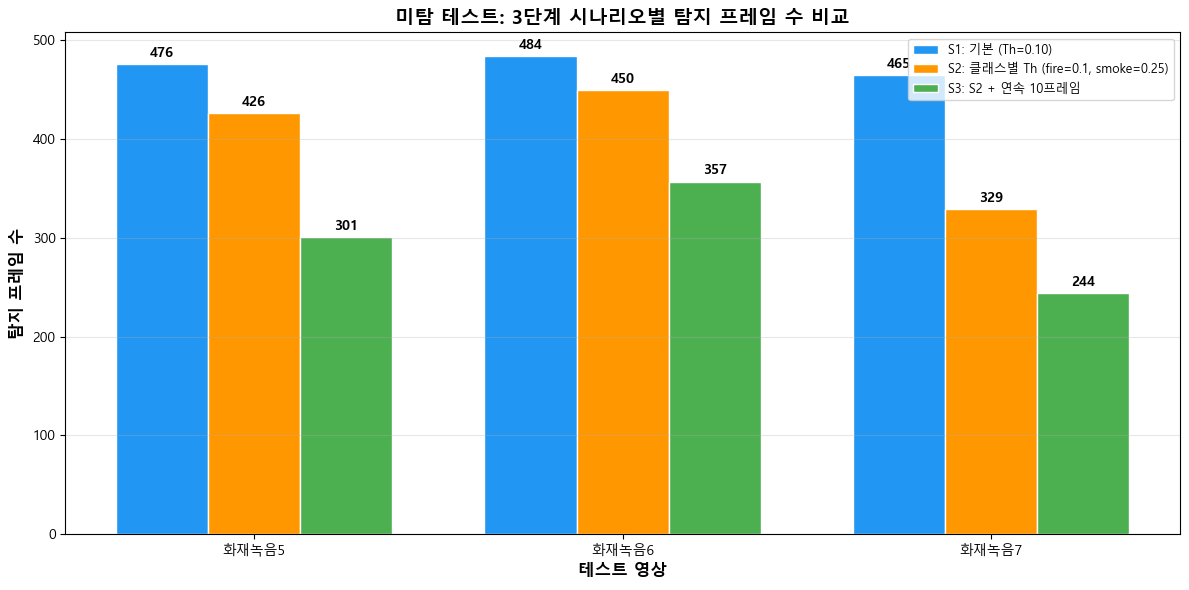

In [6]:
# ============ 시각화 1: 3단계 비교 막대 그래프 ============
# 각 영상별로 시나리오1, 2, 3의 탐지 프레임 수를 비교하는 그룹 막대 그래프

# 그래프에 사용할 데이터 준비
video_names_list = [v for v in VIDEO_INFO if v in all_results]  # 분석된 영상 이름 리스트
short_names = [v.replace('.mp4', '') for v in video_names_list]  # 짧은 이름 (확장자 제거)

# 각 시나리오별 탐지 프레임 수 리스트
s1_counts = [all_results[v]["S1"]["detected_count"] for v in video_names_list]  # 시나리오1
s2_counts = [all_results[v]["S2"]["detected_count"] for v in video_names_list]  # 시나리오2
s3_counts = [all_results[v]["S3"]["detected_count"] for v in video_names_list]  # 시나리오3 (필터 후)

# 그래프 생성
fig, ax = plt.subplots(figsize=(12, 6))  # 12x6 인치 크기의 그래프

x = np.arange(len(video_names_list))  # x축 위치 (0, 1, 2)
width = 0.25  # 막대 하나의 너비

# 3개의 막대 그룹 생성 (각 시나리오별 색상)
bars1 = ax.bar(x - width, s1_counts, width, label='S1: 기본 (Th=0.10)', color='#2196F3', edgecolor='white')  # 파란색
bars2 = ax.bar(x, s2_counts, width, label=f'S2: 클래스별 Th (fire={FIRE_THRESHOLD}, smoke={SMOKE_THRESHOLD})', color='#FF9800', edgecolor='white')  # 주황색
bars3 = ax.bar(x + width, s3_counts, width, label=f'S3: S2 + 연속 {CONSECUTIVE_FRAMES}프레임', color='#4CAF50', edgecolor='white')  # 초록색

# 막대 위에 숫자 표시
for bars in [bars1, bars2, bars3]:  # 각 막대 그룹에 대해
    for bar in bars:  # 각 막대에 대해
        height = bar.get_height()  # 막대 높이 가져오기
        ax.annotate(f'{int(height)}',  # 숫자 텍스트
                    xy=(bar.get_x() + bar.get_width() / 2, height),  # 위치 (막대 꼭대기 중앙)
                    xytext=(0, 3),  # 약간 위로 오프셋
                    textcoords="offset points",  # 오프셋 단위
                    ha='center', va='bottom',  # 중앙 정렬
                    fontsize=10, fontweight='bold')  # 폰트 설정

# 그래프 꾸미기
ax.set_xlabel('테스트 영상', fontsize=12, fontweight='bold')  # x축 레이블
ax.set_ylabel('탐지 프레임 수', fontsize=12, fontweight='bold')  # y축 레이블
ax.set_title('미탐 테스트: 3단계 시나리오별 탐지 프레임 수 비교', fontsize=14, fontweight='bold')  # 제목
ax.set_xticks(x)  # x축 눈금 위치
ax.set_xticklabels(short_names, fontsize=10)  # x축 눈금 레이블
ax.legend(fontsize=9, loc='upper right')  # 범례
ax.grid(axis='y', alpha=0.3)  # y축 격자선 (연하게)

plt.tight_layout()  # 레이아웃 자동 조정

# 저장
save_path = os.path.join(RESULT_DIR, "viz1_scenario_comparison.png")  # 저장 경로
plt.savefig(save_path, dpi=150, bbox_inches='tight')  # PNG로 저장
print(f"💾 저장: {save_path}")  # 저장 경로 출력
plt.show()  # 그래프 표시

## 셀 7: 시각화 2 — 클래스별 탐지 현황 (fire vs smoke)

💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz2_class_comparison.png


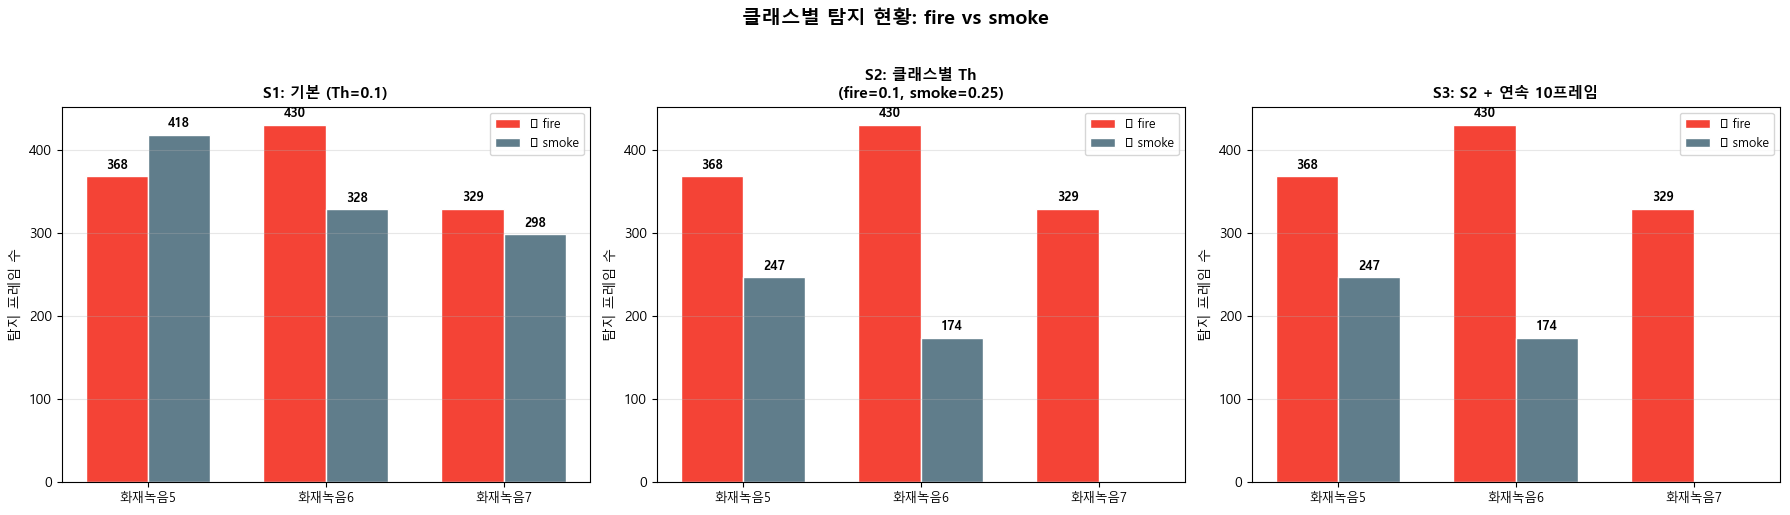

In [7]:
# ============ 시각화 2: 클래스별 탐지 현황 (fire vs smoke) ============
# 각 영상별, 시나리오별로 fire와 smoke가 각각 몇 프레임에서 탐지되었는지 비교

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1행 3열 서브플롯 (시나리오별)

scenarios = ["S1", "S2", "S3"]  # 시나리오 키 리스트
scenario_labels = [  # 시나리오 제목 리스트
    f"S1: 기본 (Th={BASE_THRESHOLD})",
    f"S2: 클래스별 Th\n(fire={FIRE_THRESHOLD}, smoke={SMOKE_THRESHOLD})",
    f"S3: S2 + 연속 {CONSECUTIVE_FRAMES}프레임"
]

for idx, (scenario, label) in enumerate(zip(scenarios, scenario_labels)):  # 각 시나리오에 대해
    ax = axes[idx]  # 해당 서브플롯 선택
    
    # fire와 smoke 탐지 프레임 수 추출
    fire_counts = [all_results[v][scenario]["fire_count"] for v in video_names_list]  # fire 프레임 수
    smoke_counts = [all_results[v][scenario]["smoke_count"] for v in video_names_list]  # smoke 프레임 수
    
    x = np.arange(len(video_names_list))  # x축 위치
    w = 0.35  # 막대 너비
    
    # 막대 그래프 생성
    b1 = ax.bar(x - w/2, fire_counts, w, label='🔥 fire', color='#F44336', edgecolor='white')  # 빨간색 (fire)
    b2 = ax.bar(x + w/2, smoke_counts, w, label='💨 smoke', color='#607D8B', edgecolor='white')  # 회색 (smoke)
    
    # 막대 위에 숫자 표시
    for bars in [b1, b2]:  # 각 막대 그룹
        for bar in bars:  # 각 막대
            h = bar.get_height()  # 높이
            if h > 0:  # 0이 아닌 경우에만 표시
                ax.annotate(f'{int(h)}', xy=(bar.get_x() + bar.get_width()/2, h),
                           xytext=(0, 3), textcoords="offset points",
                           ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(label, fontsize=11, fontweight='bold')  # 서브플롯 제목
    ax.set_xticks(x)  # x축 눈금 위치
    ax.set_xticklabels(short_names, fontsize=9)  # x축 레이블
    ax.set_ylabel('탐지 프레임 수', fontsize=10)  # y축 레이블
    ax.legend(fontsize=9)  # 범례
    ax.grid(axis='y', alpha=0.3)  # 격자선

plt.suptitle('클래스별 탐지 현황: fire vs smoke', fontsize=14, fontweight='bold', y=1.02)  # 전체 제목
plt.tight_layout()  # 레이아웃 조정

# 저장
save_path = os.path.join(RESULT_DIR, "viz2_class_comparison.png")  # 저장 경로
plt.savefig(save_path, dpi=150, bbox_inches='tight')  # 저장
print(f"💾 저장: {save_path}")  # 경로 출력
plt.show()  # 표시

## 셀 8: 시각화 3 — 영상별 탐지 타임라인

💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz3_detection_timeline.png


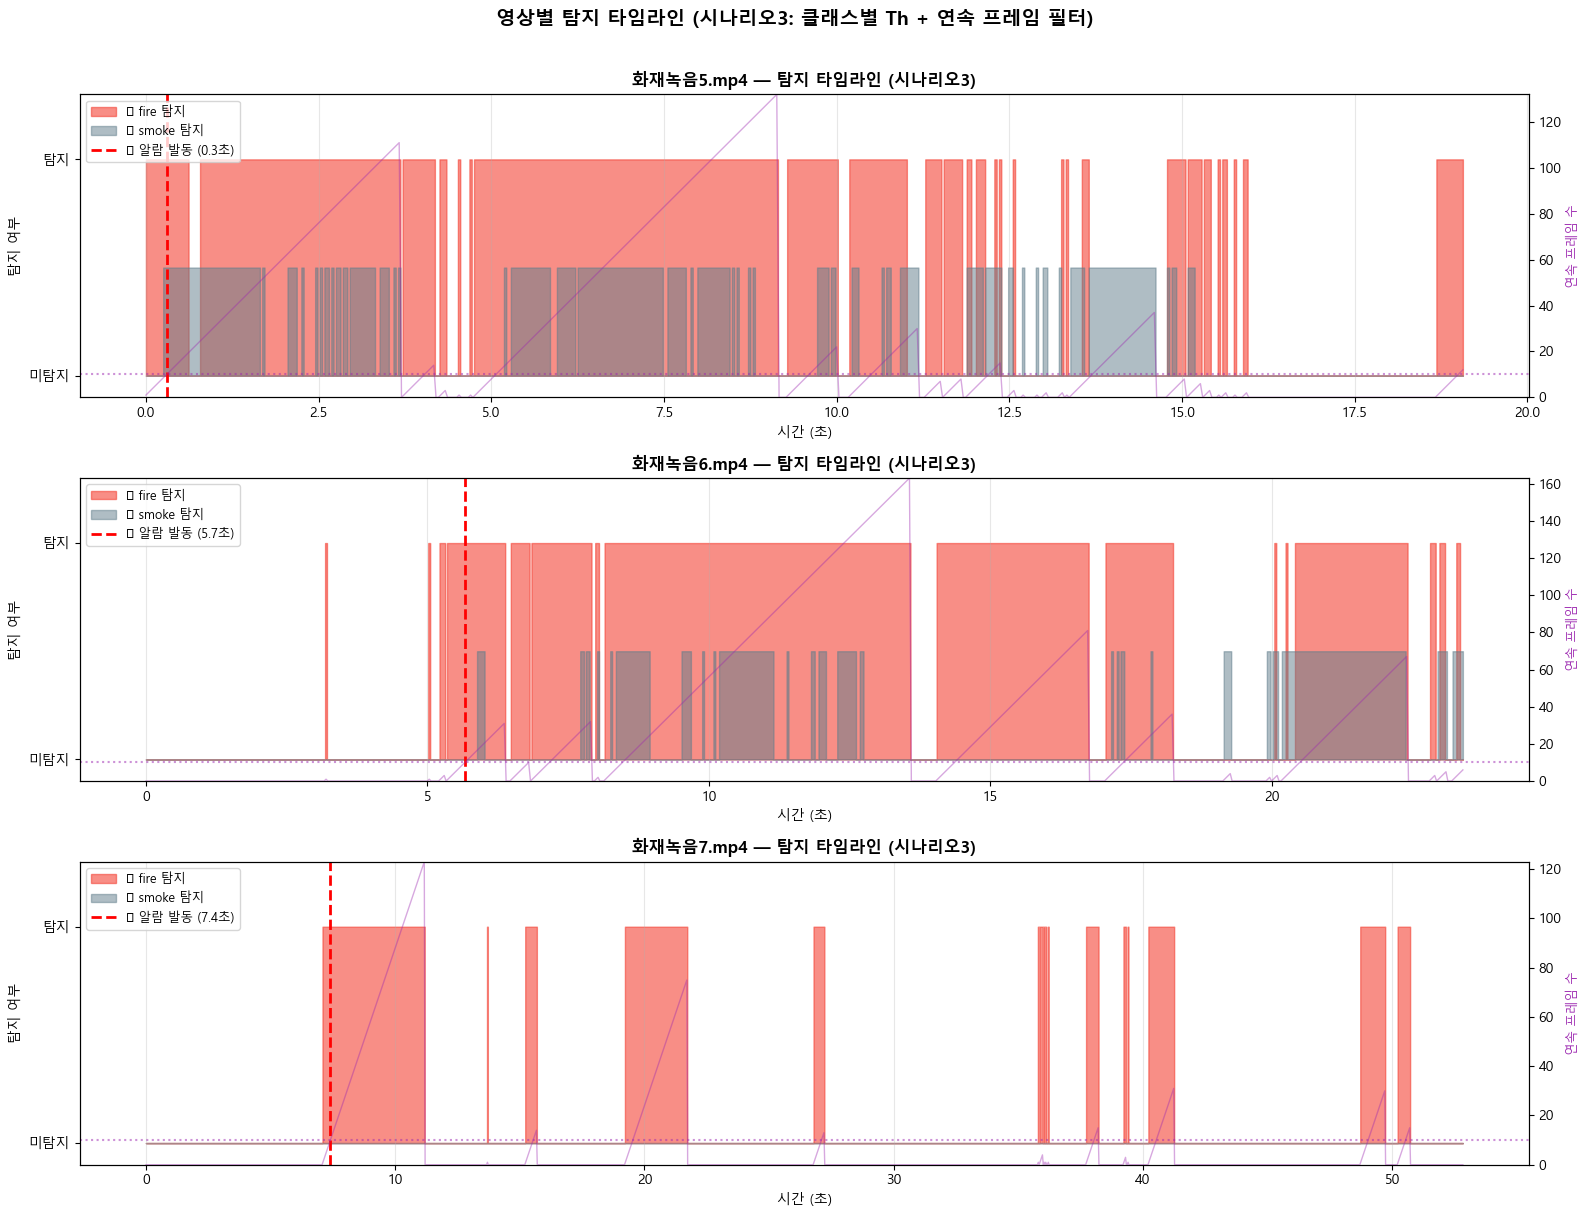

In [8]:
# ============ 시각화 3: 영상별 탐지 타임라인 ============
# 각 영상이 시간(초) 흐름에 따라 어느 시점에서 탐지되는지 시각화
# 시나리오3(가장 엄격한 조건) 기준으로 표시

n_videos = len(video_names_list)  # 분석된 영상 수
fig, axes = plt.subplots(n_videos, 1, figsize=(16, 4 * n_videos))  # 영상 수만큼 행

# axes가 1개일 때도 리스트로 처리
if n_videos == 1:  # 영상 1개인 경우
    axes = [axes]  # 리스트로 감싸기

for idx, video_name in enumerate(video_names_list):  # 각 영상에 대해
    ax = axes[idx]  # 해당 서브플롯
    
    # 시나리오3 타임라인 데이터 가져오기
    timeline = all_results[video_name]["S3"]["timeline"]  # 프레임별 타임라인
    fps = all_results[video_name]["S3"]["fps"]  # FPS
    total_frames = all_results[video_name]["S3"]["total_frames"]  # 전체 프레임
    
    # 타임라인에서 시간(초)과 탐지 정보 추출
    times = []           # 시간(초) 리스트
    fire_detections = [] # fire 탐지 여부 (0 or 1)
    smoke_detections = [] # smoke 탐지 여부 (0 or 1)
    consec_counts = []   # 연속 카운트 값
    
    for frame_num in sorted(timeline.keys()):  # 프레임 번호 순으로
        data = timeline[frame_num]  # 해당 프레임 데이터
        times.append(data["time_sec"])  # 시간 추가
        fire_detections.append(1 if data["fire"] else 0)  # fire 탐지 여부 (1/0)
        smoke_detections.append(1 if data["smoke"] else 0)  # smoke 탐지 여부
        consec_counts.append(data.get("consecutive", 0))  # 연속 카운트
    
    # fire 탐지 타임라인 (빨간색 막대)
    ax.fill_between(times, 0, fire_detections,  # 영역 채우기
                    alpha=0.6, color='#F44336', label='🔥 fire 탐지', step='mid')  # 빨간색
    
    # smoke 탐지 타임라인 (회색 막대, fire 위에 겹침)
    ax.fill_between(times, 0, [s * 0.5 for s in smoke_detections],  # 높이 0.5로 (구분용)
                    alpha=0.5, color='#607D8B', label='💨 smoke 탐지', step='mid')  # 회색
    
    # 알람 발동 시점 표시 (세로 빨간 점선)
    alarm_time = all_results[video_name]["S3"].get("alarm_time_sec", -1)  # 알람 시간
    if alarm_time >= 0:  # 알람이 발동된 경우
        ax.axvline(x=alarm_time, color='red', linestyle='--', linewidth=2,  # 빨간 점선
                   label=f'⏰ 알람 발동 ({alarm_time:.1f}초)')  # 레이블
    
    # 연속 프레임 기준선 (우측 y축에 연속 카운트 표시)
    ax2 = ax.twinx()  # 우측 y축 추가
    ax2.plot(times, consec_counts, color='#9C27B0', alpha=0.4, linewidth=1,  # 보라색 선
             label=f'연속 카운트')  # 레이블
    ax2.axhline(y=CONSECUTIVE_FRAMES, color='#9C27B0', linestyle=':', alpha=0.5)  # 기준선
    ax2.set_ylabel('연속 프레임 수', fontsize=9, color='#9C27B0')  # 우측 y축 레이블
    ax2.set_ylim(0, max(max(consec_counts) if consec_counts else 1, CONSECUTIVE_FRAMES * 1.5))  # y축 범위
    
    # 그래프 꾸미기
    ax.set_title(f'{video_name} — 탐지 타임라인 (시나리오3)', fontsize=12, fontweight='bold')  # 제목
    ax.set_xlabel('시간 (초)', fontsize=10)  # x축
    ax.set_ylabel('탐지 여부', fontsize=10)  # 좌측 y축
    ax.set_ylim(-0.1, 1.3)  # y축 범위
    ax.set_yticks([0, 1])  # y축 눈금
    ax.set_yticklabels(['미탐지', '탐지'])  # y축 레이블
    ax.legend(loc='upper left', fontsize=9)  # 범례
    ax.grid(axis='x', alpha=0.3)  # 격자선

plt.suptitle('영상별 탐지 타임라인 (시나리오3: 클래스별 Th + 연속 프레임 필터)',
             fontsize=14, fontweight='bold', y=1.01)  # 전체 제목
plt.tight_layout()  # 레이아웃 조정

# 저장
save_path = os.path.join(RESULT_DIR, "viz3_detection_timeline.png")  # 저장 경로
plt.savefig(save_path, dpi=150, bbox_inches='tight')  # 저장
print(f"💾 저장: {save_path}")  # 경로 출력
plt.show()  # 표시

## 셀 9: 시각화 4 — 최종 요약 테이블 (Heatmap 스타일)

💾 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz4_summary_heatmap.png


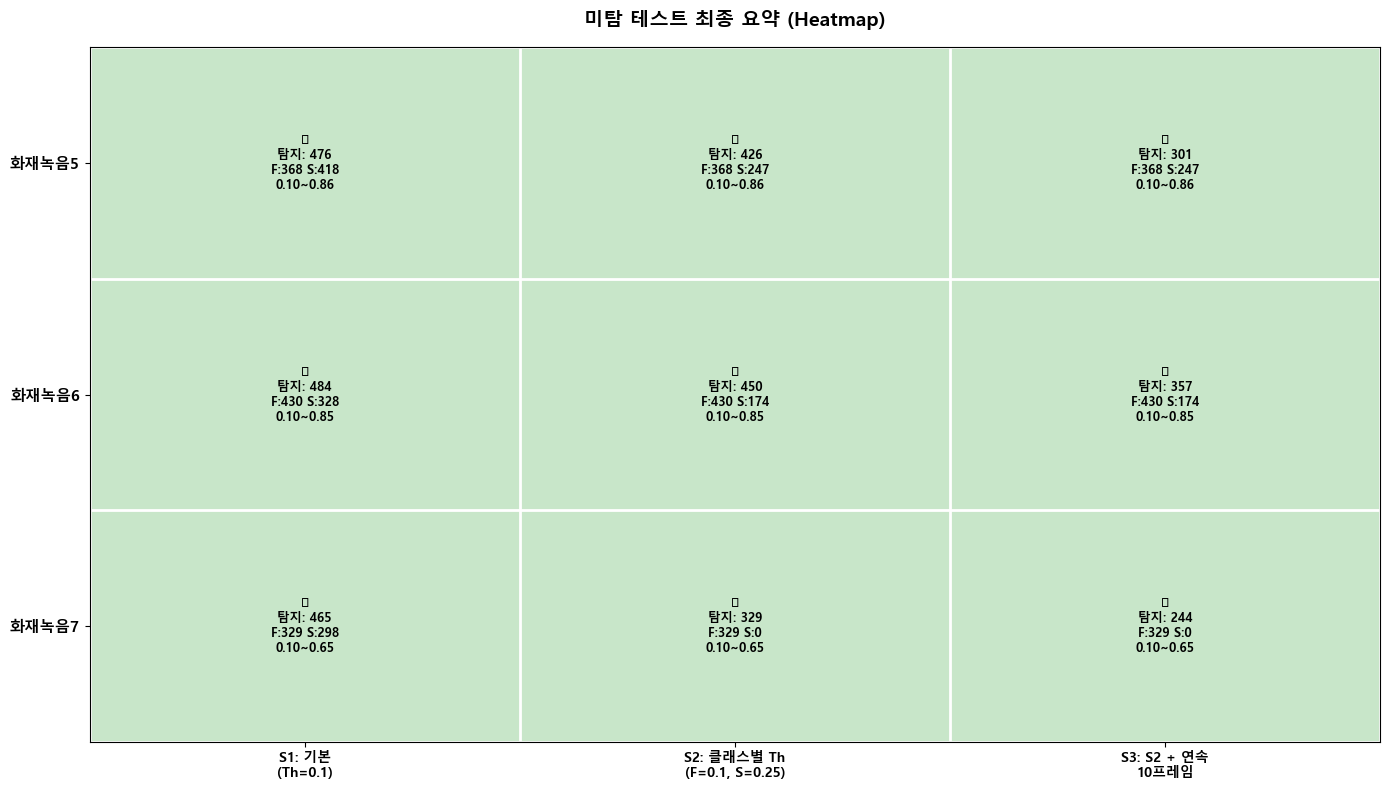

In [9]:
# ============ 시각화 4: 최종 요약 테이블 (Heatmap 스타일) ============
# 각 영상 × 각 시나리오의 탐지 성공 여부 + 상세 정보를 히트맵으로 표시

import matplotlib.colors as mcolors  # 색상 매핑용

# 요약 데이터 구성
summary_data = []  # [[영상, S1결과, S2결과, S3결과], ...] 형태
heatmap_values = []  # 히트맵 숫자 값 (PASS=1, FAIL=0)

for video_name in video_names_list:  # 각 영상
    row_text = []     # 텍스트 데이터 행
    row_values = []   # 히트맵 숫자 행
    
    for scenario in ["S1", "S2", "S3"]:  # 각 시나리오
        r = all_results[video_name][scenario]  # 결과
        
        if scenario == "S3":  # 시나리오3은 알람 기준
            is_pass = r["alarm_triggered"]  # 알람 발동 여부
        else:  # 시나리오1, 2는 탐지 프레임 수 기준
            is_pass = r["detected_count"] > 0  # 1프레임 이상 탐지
        
        row_values.append(1 if is_pass else 0)  # 1=PASS, 0=FAIL
        
        # 셀에 표시할 텍스트 구성
        status = "✅" if is_pass else "❌"  # 아이콘
        det_count = r["detected_count"]  # 탐지 프레임 수
        fire_c = r["fire_count"]  # fire 프레임 수
        smoke_c = r["smoke_count"]  # smoke 프레임 수
        conf_lo, conf_hi = r["all_conf_range"]  # confidence 범위
        
        # 텍스트 조합
        cell_text = f"{status}\n탐지: {det_count}\nF:{fire_c} S:{smoke_c}\n{conf_lo:.2f}~{conf_hi:.2f}"  # 여러 줄
        row_text.append(cell_text)  # 텍스트 행에 추가
    
    summary_data.append(row_text)  # 전체 텍스트 데이터에 추가
    heatmap_values.append(row_values)  # 히트맵 값에 추가

# 히트맵 생성
fig, ax = plt.subplots(figsize=(14, 2 + len(video_names_list) * 2))  # 크기 조정

# 커스텀 색상맵 (FAIL=빨강, PASS=초록)
cmap = mcolors.ListedColormap(['#FFCDD2', '#C8E6C9'])  # 연한 빨강, 연한 초록
bounds = [-0.5, 0.5, 1.5]  # 색상 경계 (0: FAIL, 1: PASS)
norm = mcolors.BoundaryNorm(bounds, cmap.N)  # 정규화

# 히트맵 그리기
hm = ax.imshow(heatmap_values, cmap=cmap, norm=norm, aspect='auto')  # 히트맵

# 셀 안에 텍스트 삽입
for i in range(len(video_names_list)):  # 각 행 (영상)
    for j in range(3):  # 각 열 (시나리오)
        ax.text(j, i, summary_data[i][j],  # 텍스트 내용
                ha='center', va='center', fontsize=9,  # 중앙 정렬
                fontweight='bold', color='black')  # 검정색 볼드

# 축 설정
ax.set_xticks([0, 1, 2])  # x축 눈금
ax.set_xticklabels([  # x축 레이블
    f'S1: 기본\n(Th={BASE_THRESHOLD})',
    f'S2: 클래스별 Th\n(F={FIRE_THRESHOLD}, S={SMOKE_THRESHOLD})',
    f'S3: S2 + 연속\n{CONSECUTIVE_FRAMES}프레임'
], fontsize=10, fontweight='bold')  # 폰트 설정

ax.set_yticks(range(len(video_names_list)))  # y축 눈금
ax.set_yticklabels(short_names, fontsize=11, fontweight='bold')  # y축 레이블

ax.set_title('미탐 테스트 최종 요약 (Heatmap)', fontsize=14, fontweight='bold', pad=15)  # 제목

# 테두리 그리기
for i in range(len(video_names_list) + 1):  # 행 테두리
    ax.axhline(y=i - 0.5, color='white', linewidth=2)  # 가로선
for j in range(4):  # 열 테두리
    ax.axvline(x=j - 0.5, color='white', linewidth=2)  # 세로선

plt.tight_layout()  # 레이아웃 조정

# 저장
save_path = os.path.join(RESULT_DIR, "viz4_summary_heatmap.png")  # 저장 경로
plt.savefig(save_path, dpi=150, bbox_inches='tight')  # 저장
print(f"💾 저장: {save_path}")  # 경로 출력
plt.show()  # 표시

## 셀 10: 시각화 5 — 탐지된 프레임 샘플 이미지 저장


📸 샘플 프레임 이미지 저장 중...

  💾 화재녹음5.mp4: 3장 저장 → N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz5_sample_화재녹음5.png


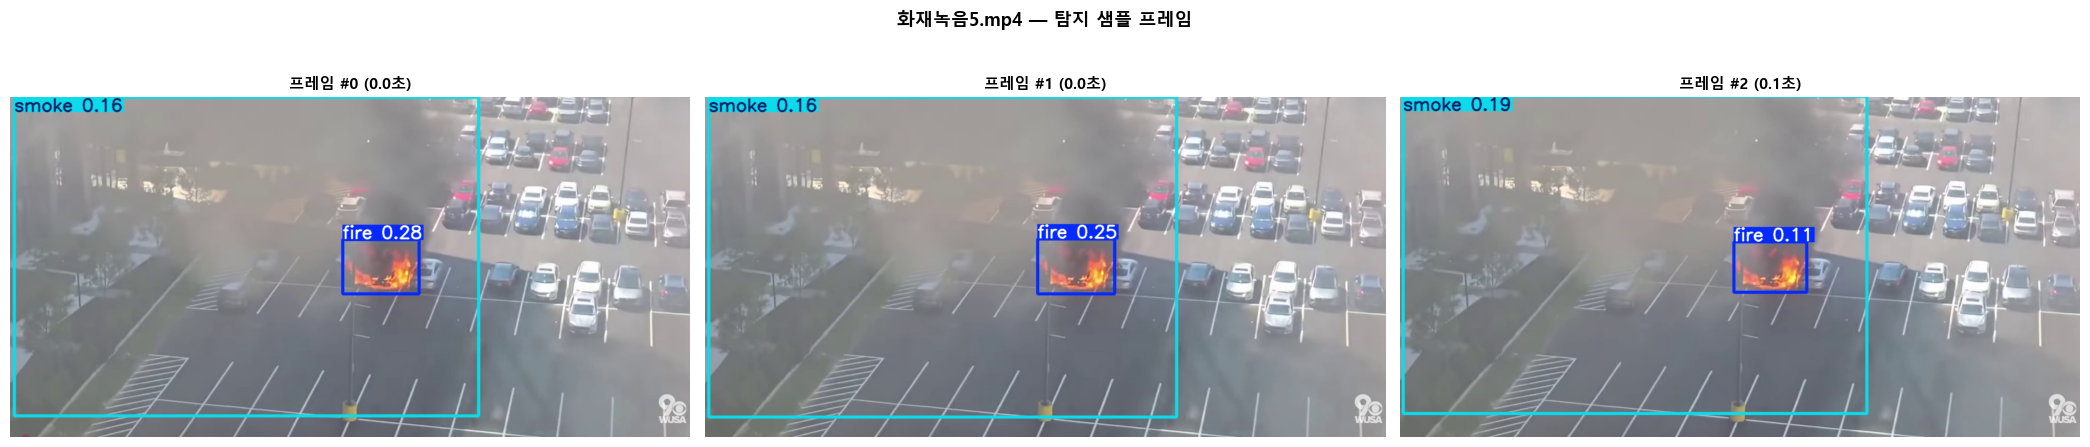

     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음5_frame0.png
     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음5_frame1.png
     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음5_frame2.png
  💾 화재녹음6.mp4: 3장 저장 → N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz5_sample_화재녹음6.png


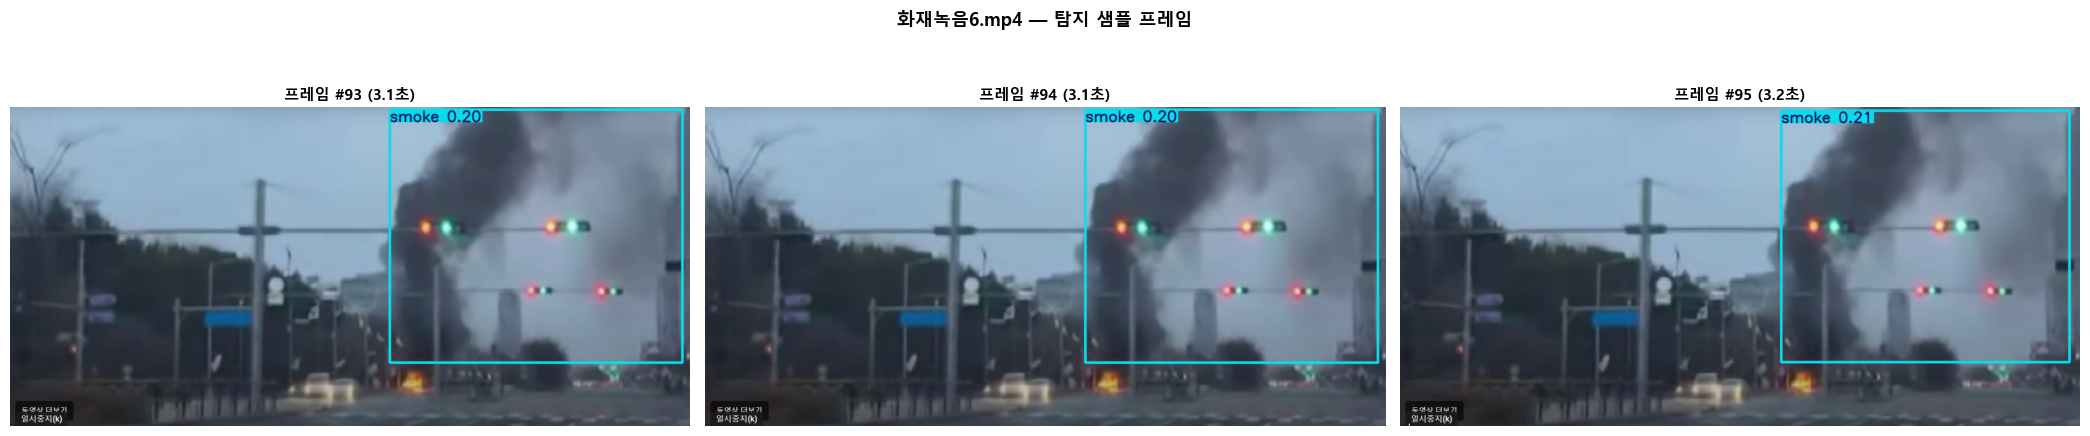

     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음6_frame93.png
     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음6_frame94.png
     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음6_frame95.png
  💾 화재녹음7.mp4: 3장 저장 → N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\viz5_sample_화재녹음7.png


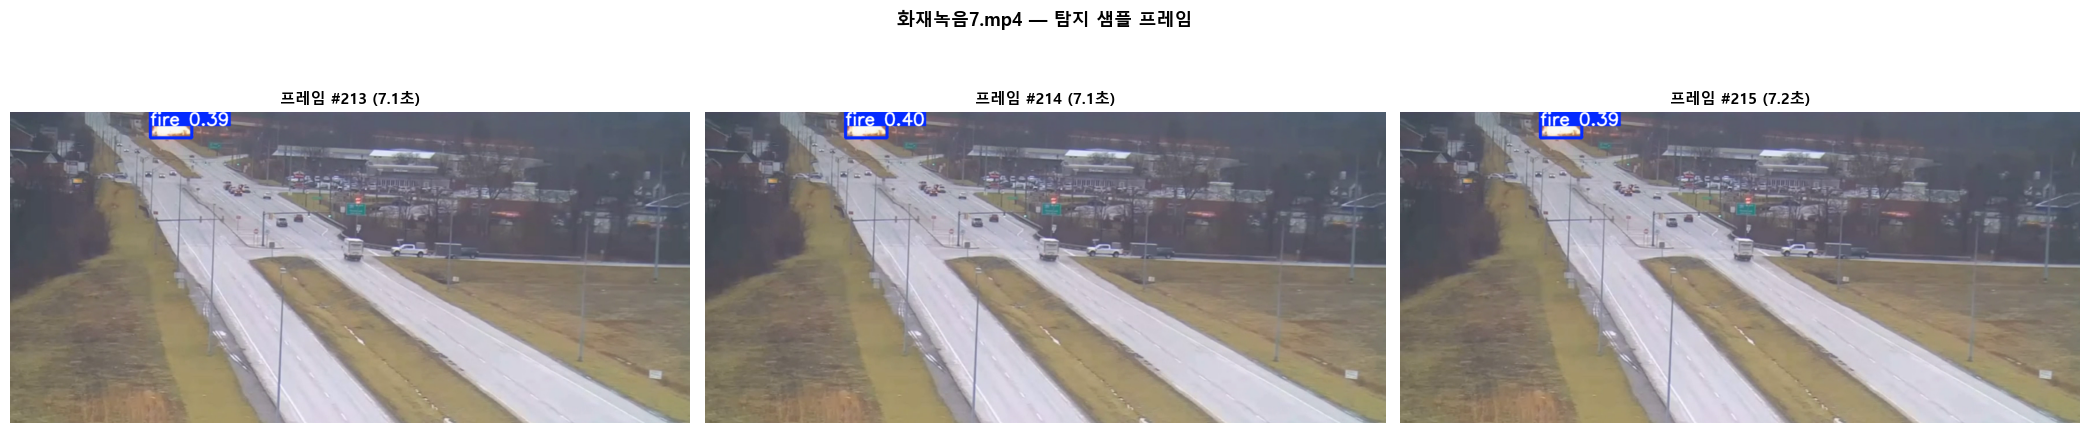

     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음7_frame213.png
     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음7_frame214.png
     개별 저장: N:\개인\이수빈\3.13_Mini_Project\results\false_negative_test\sample_화재녹음7_frame215.png

✅ 샘플 프레임 저장 완료!


In [10]:
# ============ 시각화 5: 탐지된 프레임 샘플 이미지 저장 ============
# 각 영상의 시나리오1(가장 많은 탐지) 결과에서 샘플 프레임 이미지를 저장

print("\n📸 샘플 프레임 이미지 저장 중...\n")  # 시작 메시지

for video_name in video_names_list:  # 각 영상에 대해
    samples = all_results[video_name]["S1"]["sample_frames"]  # 시나리오1의 샘플 프레임
    short = video_name.replace('.mp4', '')  # 짧은 이름
    
    if not samples:  # 샘플이 없으면
        print(f"  ⚠️ {video_name}: 탐지된 프레임 없음 (샘플 저장 불가)")  # 경고
        continue  # 다음 영상으로
    
    # 서브플롯으로 샘플들을 한 이미지에 표시
    n_samples = len(samples)  # 샘플 수
    fig, axes_sample = plt.subplots(1, n_samples, figsize=(7 * n_samples, 5))  # 1행 N열
    
    if n_samples == 1:  # 샘플 1개면 리스트로 감싸기
        axes_sample = [axes_sample]
    
    for i, sample in enumerate(samples):  # 각 샘플에 대해
        img_rgb = cv2.cvtColor(sample["image"], cv2.COLOR_BGR2RGB)  # BGR → RGB 변환 (matplotlib용)
        axes_sample[i].imshow(img_rgb)  # 이미지 표시
        axes_sample[i].set_title(  # 제목 (프레임 번호와 시간)
            f'프레임 #{sample["frame_idx"]} ({sample["time_sec"]:.1f}초)',
            fontsize=11, fontweight='bold'
        )
        axes_sample[i].axis('off')  # 축 숨기기
    
    plt.suptitle(f'{video_name} — 탐지 샘플 프레임', fontsize=13, fontweight='bold')  # 전체 제목
    plt.tight_layout()  # 레이아웃
    
    # 저장
    save_path = os.path.join(RESULT_DIR, f"viz5_sample_{short}.png")  # 저장 경로
    plt.savefig(save_path, dpi=150, bbox_inches='tight')  # 저장
    print(f"  💾 {video_name}: {n_samples}장 저장 → {save_path}")  # 경로 출력
    plt.show()  # 표시

    # 개별 프레임도 따로 저장 (고해상도)
    for i, sample in enumerate(samples):  # 각 샘플에 대해
        individual_path = os.path.join(RESULT_DIR, f"sample_{short}_frame{sample['frame_idx']}.png")  # 개별 저장 경로
        cv2.imwrite(individual_path, sample["image"])  # OpenCV로 저장 (원본 해상도)
        print(f"     개별 저장: {individual_path}")  # 경로 출력

print("\n✅ 샘플 프레임 저장 완료!")  # 완료 메시지

## 셀 11: 최종 종합 리포트 출력

In [11]:
# ============ 최종 종합 리포트 ============
# 모든 결과를 텍스트로 정리하여 한눈에 볼 수 있게 출력

print("\n" + "=" * 80)  # 구분선
print("📋 미탐(False Negative) 테스트 — 최종 종합 리포트")  # 제목
print("=" * 80)  # 구분선

print(f"\n📌 테스트 설정:")  # 설정 섹션
print(f"   모델: YOLOv8n Tuned (best.pt)")  # 모델
print(f"   장치: {DEVICE}")  # 장치
print(f"   기본 Threshold: {BASE_THRESHOLD}")  # 시나리오1
print(f"   Fire Threshold: {FIRE_THRESHOLD}")  # 시나리오2,3
print(f"   Smoke Threshold: {SMOKE_THRESHOLD}")  # 시나리오2,3
print(f"   연속 프레임 기준: {CONSECUTIVE_FRAMES}프레임")  # 시나리오3

print(f"\n" + "-" * 80)  # 구분선

for video_name in video_names_list:  # 각 영상
    info = VIDEO_INFO[video_name]  # 영상 정보
    print(f"\n🎬 {video_name} ({info['start']}, {info['type']}, 크기: {info['size']})")  # 영상 정보
    print(f"   {'시나리오':<30} {'판정':<10} {'탐지 프레임':<15} {'fire':<10} {'smoke':<10} {'Conf 범위':<20}")  # 헤더
    print(f"   {'-'*95}")  # 구분선
    
    for scenario, label in [("S1", f"기본 (Th={BASE_THRESHOLD})"),  # 시나리오1
                             ("S2", f"클래스별 (F={FIRE_THRESHOLD},S={SMOKE_THRESHOLD})"),  # 시나리오2
                             ("S3", f"S2 + 연속 {CONSECUTIVE_FRAMES}프레임")]:  # 시나리오3
        r = all_results[video_name][scenario]  # 결과
        
        # 판정 결정
        if scenario == "S3":  # 시나리오3
            is_pass = r["alarm_triggered"]  # 알람 기준
        else:  # 시나리오1, 2
            is_pass = r["detected_count"] > 0  # 탐지 수 기준
        
        status = "✅ PASS" if is_pass else "❌ FAIL"  # 상태
        conf_lo, conf_hi = r["all_conf_range"]  # confidence 범위
        conf_str = f"{conf_lo:.3f}~{conf_hi:.3f}" if conf_lo > 0 else "N/A"  # 문자열 변환
        
        print(f"   {label:<30} {status:<10} {r['detected_count']:<15} {r['fire_count']:<10} {r['smoke_count']:<10} {conf_str:<20}")  # 행 출력
    
    # 시나리오3 알람 상세
    s3 = all_results[video_name]["S3"]  # 시나리오3 결과
    if s3["alarm_triggered"]:  # 알람 발동 시
        print(f"   ⏰ 알람 발동 시점: {s3['alarm_time_sec']:.1f}초 (프레임 #{s3['alarm_frame']})")  # 시간
    else:  # 미발동
        print(f"   ⚠️ 알람 미발동 (필터 전 탐지: {s3['raw_detected_count']}프레임)")  # 경고

# 최종 결론
print(f"\n" + "=" * 80)  # 구분선
print("🏁 최종 결론")  # 제목
print("=" * 80)  # 구분선

# 전체 통과 여부 다시 확인
total_tests = 0      # 전체 테스트 수
passed_tests = 0     # 통과 테스트 수
failed_items = []    # 실패 항목 리스트

for video_name in video_names_list:  # 각 영상
    for scenario in ["S1", "S2", "S3"]:  # 각 시나리오
        total_tests += 1  # 테스트 수 증가
        if tdd_results.get(video_name, {}).get(scenario, False):  # 통과 여부
            passed_tests += 1  # 통과 수 증가
        else:  # 실패
            failed_items.append(f"{video_name} - {scenario}")  # 실패 항목 추가

print(f"\n  테스트 결과: {passed_tests}/{total_tests} PASS")  # 결과 요약

if passed_tests == total_tests:  # 전체 통과
    print("  🎉 ALL PASS: 후처리(클래스별 Threshold + 연속 프레임 필터) 적용 후에도")  # 성공 메시지1
    print("     모든 화재 영상을 정상 탐지합니다.")  # 성공 메시지2
    print("     → 오탐 감소 후처리가 미탐을 유발하지 않음을 확인!")  # 결론
else:  # 실패 있음
    print(f"  ⚠️ FAIL 항목 ({len(failed_items)}건):")  # 실패 수
    for item in failed_items:  # 각 실패 항목
        print(f"     - {item}")  # 출력
    print("\n  💡 조치 방안:")  # 조치 안내
    print("     1. Smoke Threshold를 낮춰보기 (0.25 → 0.20)")  # 방안1
    print("     2. 연속 프레임 수를 줄여보기 (10 → 7)")  # 방안2
    print("     3. 해당 영상의 화재 특성 분석 (크기, 연기 농도 등)")  # 방안3

# 저장된 파일 목록
print(f"\n" + "-" * 80)  # 구분선
print("📁 저장된 파일 목록:")  # 제목
print(f"   결과 폴더: {RESULT_DIR}")  # 폴더 경로
for f in sorted(os.listdir(RESULT_DIR)):  # 폴더 내 파일 순회
    fpath = os.path.join(RESULT_DIR, f)  # 전체 경로
    fsize = os.path.getsize(fpath) / 1024  # KB 단위 크기
    print(f"   - {f} ({fsize:.1f} KB)")  # 파일명과 크기

print(f"\n{'='*80}")  # 구분선
print("✅ 미탐 테스트 완료!")  # 완료
print(f"{'='*80}")  # 구분선


📋 미탐(False Negative) 테스트 — 최종 종합 리포트

📌 테스트 설정:
   모델: YOLOv8n Tuned (best.pt)
   장치: cpu
   기본 Threshold: 0.1
   Fire Threshold: 0.1
   Smoke Threshold: 0.25
   연속 프레임 기준: 10프레임

--------------------------------------------------------------------------------

🎬 화재녹음5.mp4 (0초부터, 연기+불꽃, 크기: 보통)
   시나리오                           판정         탐지 프레임          fire       smoke      Conf 범위             
   -----------------------------------------------------------------------------------------------
   기본 (Th=0.1)                    ✅ PASS     476             368        418        0.100~0.860         
   클래스별 (F=0.1,S=0.25)            ✅ PASS     426             368        247        0.100~0.860         
   S2 + 연속 10프레임                  ✅ PASS     301             368        247        0.100~0.860         
   ⏰ 알람 발동 시점: 0.3초 (프레임 #9)

🎬 화재녹음6.mp4 (0초부터, 연기+불꽃, 크기: 보통)
   시나리오                           판정         탐지 프레임          fire       smoke      Conf 범위             
   -----------------